In [1]:
import math

def classifyAPoint(points,p,k=3):
    '''
     This function finds the classification of p using
     k nearest neighbor algorithm. It assumes only two
     groups and returns 0 if p belongs to group 0, else
      1 (belongs to group 1).

      Parameters - 
          points: Dictionary of training points having two keys - 0 and 1
                   Each key have a list of training data points belong to that 

          p : A tuple, test data point of the form (x,y)

          k : number of nearest neighbour to consider, default is 3 
    '''

    distance=[]
    for group in points:
        for feature in points[group]:

            #calculate the euclidean distance of p from training points 
            euclidean_distance = math.sqrt((feature[0]-p[0])**2 +(feature[1]-p[1])**2)

            # Add a tuple of form (distance,group) in the distance list
            distance.append((euclidean_distance,group))

    # sort the distance list in ascending order
    # and select first k distances
    
    distance = sorted(distance)[:k]
    print(f'distance: {distance}, k: {k}')

    freq1 = 0 #frequency of group 0
    freq2 = 0 #frequency og group 1

    for d in distance:
        if d[1] == 0:
            freq1 += 1
        elif d[1] == 1:
            freq2 += 1

    return 0 if freq1>freq2 else 1


# Dictionary of training points having two keys - 0 and 1
# key 0 have points belong to class 0
# key 1 have points belong to class 1

points = {0:[(1,12),(2,5),(3,6),(3,10),(3.5,8),(2,11),(2,9),(1,7)],
            1:[(5,3),(3,2),(1.5,9),(7,2),(6,1),(3.8,1),(5.6,4),(4,2),(2,5)]}

# testing point p(x,y) 
p = (2.5,7)

# Number of neighbours 
k = 17

print("The value classified to unknown point is: {}".\
        format(classifyAPoint(points,p,k)))

distance: [(1.118033988749895, 0), (1.4142135623730951, 0), (1.5, 0), (2.0615528128088303, 0), (2.0615528128088303, 0), (2.0615528128088303, 1), (2.23606797749979, 1), (3.0413812651491097, 0), (4.031128874149275, 0), (4.313930922024598, 1), (4.716990566028302, 1), (5.024937810560445, 1), (5.220153254455275, 0), (5.220153254455275, 1), (6.139218191268331, 1), (6.726812023536855, 1), (6.946221994724902, 1)], k: 17
The value classified to unknown point is: 1


Optimal k value: 10
Best average cross-validation accuracy: 0.9800


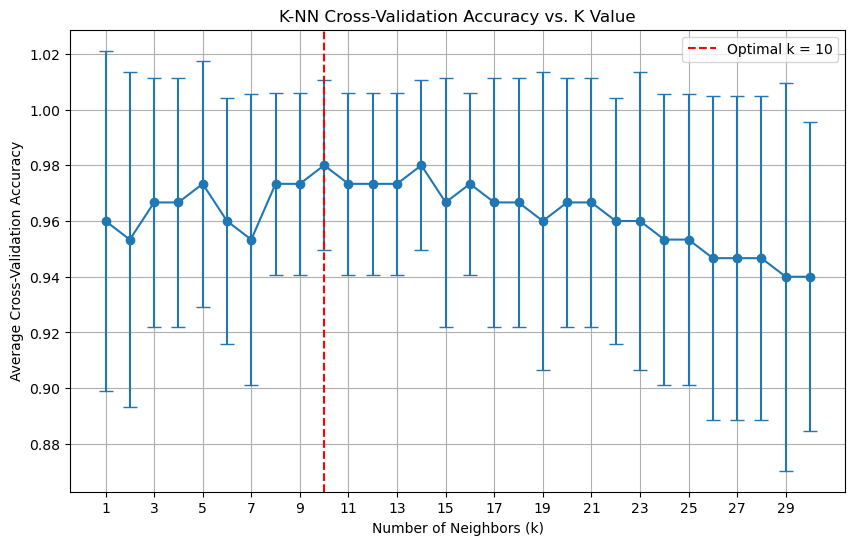

In [ ]:
# Hyperparameter tuning for k in K-NN using cross-validation

import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# Load the Iris dataset as an example
iris = load_iris()
X = iris.data
y = iris.target

# Define a range of k values to test
k_values = list(range(1, 31)) # Testing k from 1 to 30

# Store the average accuracy for each k
avg_accuracies = []
std_accuracies = []

# Perform 10-fold cross-validation for each k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    # KFold ensures that each fold has a consistent split for reproducibility and fair comparison
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(knn, X, y, cv=kf, scoring='accuracy')
    avg_accuracies.append(scores.mean())
    std_accuracies.append(scores.std())

# Find the k value with the highest average accuracy
optimal_k_index = np.argmax(avg_accuracies)
optimal_k = k_values[optimal_k_index]
best_accuracy = avg_accuracies[optimal_k_index]

print(f"Optimal k value: {optimal_k}")
print(f"Best average cross-validation accuracy: {best_accuracy:.4f}")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.errorbar(k_values, avg_accuracies, yerr=std_accuracies, fmt='-o', capsize=5)
plt.title('K-NN Cross-Validation Accuracy vs. K Value')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Average Cross-Validation Accuracy')
plt.xticks(k_values[::2]) # Show every second k value for better readability
plt.grid(True)
plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal k = {optimal_k}')
plt.legend()
plt.show()